# Parking Occupancy MVP — Voxel51/PKLot + 3 Approaches (Colab)

**Dataset:** [`Voxel51/PKLot`](https://huggingface.co/datasets/Voxel51/PKLot) (CC BY 4.0, Almeida et al. 2015)

### How to run
1. Upload this notebook **and** `requirements.txt` to [Google Colab](https://colab.research.google.com/)
2. **Runtime → GPU (T4)**
3. Run the **install cell once** — it will **auto-restart** the runtime after fixing Pillow (expected).
4. After reconnect, **Run all** again (install cell will no-op).

| # | Approach | Idea | Needs parking training? |
|---|----------|------|-------------------------|
| **A** | Patch CNN classifier | Crop each ROI → free/occupied small CNN | Yes (on PKLot patches) |
| **B** | YOLOv8n boxes + ROI overlap | Detect cars, score ROI coverage | No (COCO pretrained) |
| **C** | YOLOv8n-seg masks + ROI IoU | Segment cars, IoU with ROI mask | No (COCO pretrained) |


## 0 · Install (Pillow fixed last — Colab Python 3.13)


In [1]:
# Upload requirements.txt to /content/ (Files sidebar) before running.
# This cell installs deps, repairs Pillow, then HARD-RESTARTS the runtime once.
# That restart is required on Colab Python 3.13 — otherwise torchvision/fiftyone keep a broken PIL in memory.
import os
import subprocess
import sys
from pathlib import Path

FLAG = Path("/content/.parking_mvp_deps_ok")
candidates = [
    Path("requirements.txt"),
    Path("/content/requirements.txt"),
    Path("/content/parking-slot-detection/requirements.txt"),
]
req = next((p for p in candidates if p.is_file()), None)

if FLAG.exists():
    import PIL
    print("Deps already installed. Pillow:", PIL.__version__)
    print("Continue with the next cells.")
else:
    if req is None:
        raise FileNotFoundError(
            "requirements.txt not found. Upload it to /content/ then re-run this cell."
        )
    print("Installing from", req.resolve())
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "-r", str(req)])
    # fiftyone/ultralytics often leave a mixed Pillow install — wipe and reinstall LAST
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "pillow", "PIL"], stderr=subprocess.DEVNULL)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "--no-cache-dir", "--force-reinstall", "pillow==11.2.1"]
    )
    FLAG.write_text("ok\n")
    print("Pillow repaired. Restarting runtime now (normal)...")
    print("After reconnect: Runtime → Run all")
    os.kill(os.getpid(), 9)


Deps already installed. Pillow: 11.2.1
Continue with the next cells.


In [2]:
from __future__ import annotations

import json
import random
import shutil
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display, Markdown
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# No torchvision / no PIL imports here — they trigger Colab's broken _Ink error.

ROOT = Path("/content/parking_mvp") if Path("/content").exists() else Path.cwd() / "parking_mvp_colab_run"
DATA, FRAMES, OUT, REPORTS = ROOT / "data", ROOT / "data" / "frames", ROOT / "outputs", ROOT / "reports"
for p in (DATA, FRAMES, OUT, REPORTS):
    p.mkdir(parents=True, exist_ok=True)

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("ROOT =", ROOT, "| device =", DEVICE)


ROOT = /content/parking_mvp | device = cpu


## 1 · Load Voxel51/PKLot

**Important:** `datasets.load_dataset("Voxel51/PKLot")` exposes **images only** (no spot polygons).
The same Hub repo stores polygons + occupancy via **FiftyOne**. We:

1. Call `load_dataset` as requested (and keep a small image subset)
2. Load a capped labeled view with FiftyOne for ROIs + GT


/usr/local/lib/python3.13/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


Loading via datasets.load_dataset('Voxel51/PKLot', streaming=True) ...


README.md:   0%|          | 0.00/14.1k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/12419 [00:00<?, ?it/s]

IterableDataset({
    features: ['image'],
    num_shards: 1
})


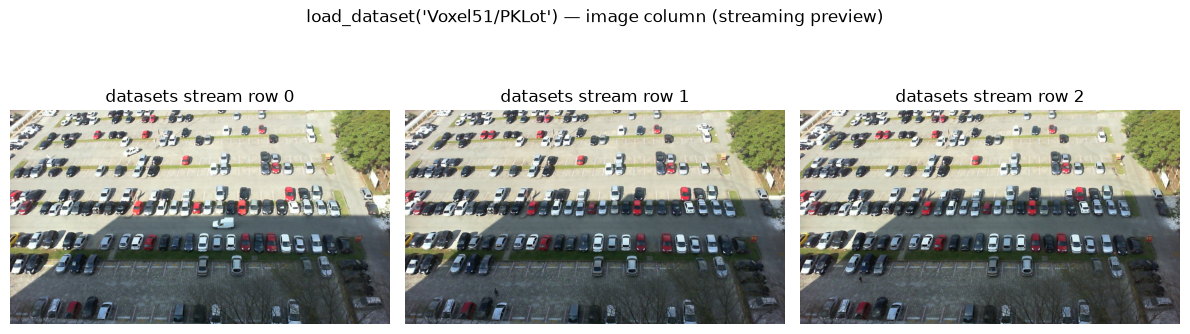


Loading labeled subset via FiftyOne load_from_hub (annotations)...


INFO:fiftyone.utils.huggingface:Downloading config file fiftyone.yml from Voxel51/PKLot


fiftyone.yml:   0%|          | 0.00/84.0 [00:00<?, ?B/s]

Loading dataset


INFO:fiftyone.utils.huggingface:Loading dataset


...

INFO:eta.core.utils: 100% |█████████████████| 400/400 [223.9ms elapsed, 0s remaining, 1.8K samples/s]     


INFO:fiftyone.utils.huggingface:Downloading 400 media files...
100%|██████████| 4/4 [00:38<00:00,  9.54s/it]

Using lot='pucpr', weather filter='sunny', frames=80


Export labeled frames:   0%|          | 0/80 [00:00<?, ?it/s]

Exported 80 frames → /content/parking_mvp/data/frames
Example spots: 24 GT free/occ: 24 0


In [3]:
from datasets import load_dataset
import fiftyone as fo
from fiftyone.utils.huggingface import load_from_hub

MAX_FRAMES = 80          # keep Colab disk/time reasonable (full set is 12k / ~4GB)
MAX_SPOTS_PER_FRAME = 24 # project scope: 10–30 spots
WEATHER = "sunny"        # daytime feasibility target

# --- 1a. User-requested API (images) ---
# Full parquet is ~4GB. Use streaming for a quick preview; labeled work uses FiftyOne below.
print("Loading via datasets.load_dataset('Voxel51/PKLot', streaming=True) ...")
ds = load_dataset("Voxel51/PKLot", split="train", streaming=True)
print(ds)
preview_rows = list(ds.take(3))
fig, axes = plt.subplots(1, len(preview_rows), figsize=(12, 4))
if len(preview_rows) == 1:
    axes = [axes]
for i, (ax, row) in enumerate(zip(axes, preview_rows)):
    ax.imshow(row["image"])
    ax.set_title(f"datasets stream row {i}")
    ax.axis("off")
plt.suptitle("load_dataset('Voxel51/PKLot') — image column (streaming preview)")
plt.tight_layout()
plt.show()

# Non-streaming handle (same API the Hub card shows). Comment in if you have disk for ~4GB:
# ds_full = load_dataset("Voxel51/PKLot", split="train")

# --- 1b. Labeled subset (polygons + occupancy) via FiftyOne on the SAME repo ---
print("\nLoading labeled subset via FiftyOne load_from_hub (annotations)...")
fo_ds = load_from_hub("Voxel51/PKLot", max_samples=400, overwrite=True)
view = fo_ds.match(fo.ViewField("weather.label") == WEATHER)
if len(view) < 20:
    print("Few sunny samples; using all weather.")
    view = fo_ds.view()

# Stay on ONE lot so space_ids are comparable across frames
sources = view.distinct("source")
best_source = max(sources, key=lambda s: len(view.match(fo.ViewField("source") == s)))
view = view.match(fo.ViewField("source") == best_source).sort_by("parking_timestamp").limit(MAX_FRAMES)
print(f"Using lot={best_source!r}, weather filter={WEATHER!r}, frames={len(view)}")


def _pl_attr(pl, name, default=None):
    if hasattr(pl, name) and getattr(pl, name) is not None:
        return getattr(pl, name)
    attrs = getattr(pl, "attributes", None) or {}
    if name in attrs:
        val = attrs[name]
        return getattr(val, "value", val)
    try:
        return pl[name]
    except Exception:
        return default


def occ_label(raw) -> str:
    s = str(raw or "unknown").lower().replace(" ", "_")
    if s in ("not_occupied", "not-occupied", "vacant", "free"):
        return "free"
    if s in ("occupied", "busy"):
        return "occupied"
    return "unknown"


if FRAMES.exists():
    shutil.rmtree(FRAMES)
FRAMES.mkdir(parents=True, exist_ok=True)

manifest = []
for i, sample in enumerate(tqdm(view, desc="Export labeled frames")):
    img = cv2.imread(sample.filepath)
    if img is None:
        continue
    h, w = img.shape[:2]
    dst = FRAMES / f"frame_{i:04d}.jpg"
    cv2.imwrite(str(dst), img)

    spaces = []
    if sample.parking_spaces is not None:
        for pl in sample.parking_spaces.polylines:
            status = occ_label(_pl_attr(pl, "occupancy_status"))
            if status == "unknown":
                continue
            pts = [[float(x), float(y)] for x, y in pl.points[0]]
            poly = [[int(round(x * w)), int(round(y * h))] for x, y in pts]
            sid = _pl_attr(pl, "space_id", len(spaces) + 1)
            spaces.append({
                "id": f"S{int(sid):03d}",
                "polygon": poly,
                "polygon_norm": pts,
                "gt": status,
            })

    spaces = sorted(spaces, key=lambda s: abs(cv2.contourArea(np.array(s["polygon"], np.float32))), reverse=True)
    spaces = spaces[:MAX_SPOTS_PER_FRAME]

    manifest.append({
        "frame": dst.name,
        "source": sample.source,
        "weather": sample.weather.label if sample.weather else None,
        "width": w,
        "height": h,
        "spaces": spaces,
    })

(DATA / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(f"Exported {len(manifest)} frames → {FRAMES}")
print("Example spots:", len(manifest[0]["spaces"]), "GT free/occ:",
      sum(s["gt"]=="free" for s in manifest[0]["spaces"]),
      sum(s["gt"]=="occupied" for s in manifest[0]["spaces"]))


## 2 · `rois.json` (reference frame)


Wrote /content/parking_mvp/data/rois.json n= 24


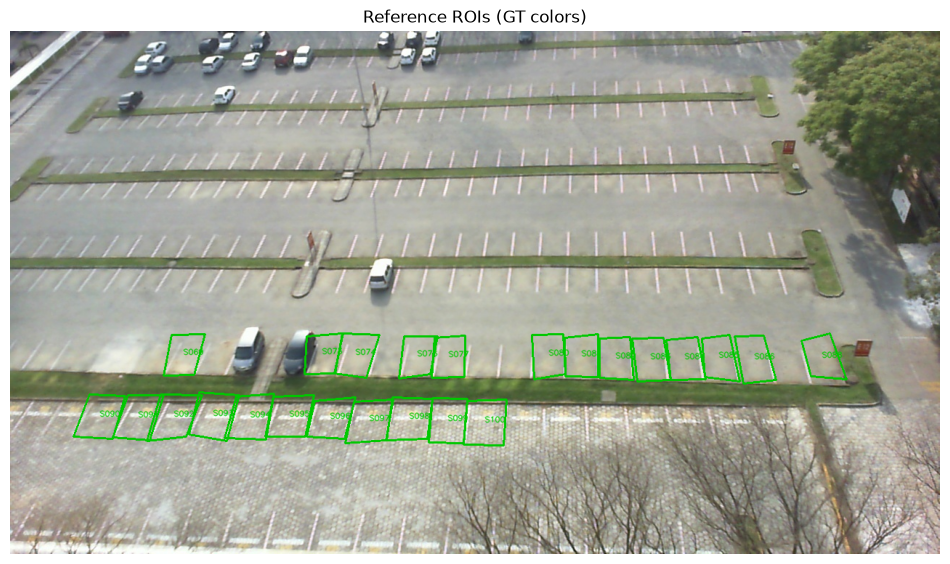

In [4]:
def load_bgr(path: Path) -> np.ndarray:
    im = cv2.imread(str(path))
    if im is None:
        raise FileNotFoundError(path)
    return im


def overlay_rois(image, spots, statuses=None):
    vis = image.copy()
    for spot in spots:
        pts = np.array(spot["polygon"], np.int32)
        st = (statuses or {}).get(spot["id"], spot.get("gt", "unknown"))
        color = (0, 200, 0) if st == "free" else (0, 0, 220) if st == "occupied" else (160, 160, 160)
        cv2.polylines(vis, [pts], True, color, 2)
        c = pts.mean(0).astype(int)
        cv2.putText(vis, spot["id"], tuple(c), cv2.FONT_HERSHEY_SIMPLEX, 0.35, color, 1, cv2.LINE_AA)
    return vis


ref = manifest[0]
ref_img = load_bgr(FRAMES / ref["frame"])
rois = {
    "camera_id": f"pklot_{ref['source']}",
    "image_size": {"width": ref["width"], "height": ref["height"]},
    "source_frame": ref["frame"],
    "spots": [{"id": s["id"], "polygon": s["polygon"], "polygon_norm": s["polygon_norm"]} for s in ref["spaces"]],
    "notes": "From Voxel51/PKLot polygons on reference frame",
}
(DATA / "rois.json").write_text(json.dumps(rois, indent=2))
print("Wrote", DATA / "rois.json", "n=", len(rois["spots"]))

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(overlay_rois(ref_img, ref["spaces"]), cv2.COLOR_BGR2RGB))
plt.title("Reference ROIs (GT colors)")
plt.axis("off")
plt.show()


## 3 · Shared helpers (metrics, crops, masks)


In [5]:
def polygon_mask(hw, polygon):
    m = np.zeros(hw, np.uint8)
    cv2.fillPoly(m, [np.array(polygon, np.int32)], 1)
    return m


def crop_roi(image_bgr, polygon, out_size=128):
    pts = np.array(polygon, np.float32)
    x, y, w, h = cv2.boundingRect(pts.astype(np.int32))
    x2, y2 = x + w, y + h
    H, W = image_bgr.shape[:2]
    x, y = max(0, x), max(0, y)
    x2, y2 = min(W, x2), min(H, y2)
    patch = image_bgr[y:y2, x:x2]
    if patch.size == 0:
        patch = np.zeros((out_size, out_size, 3), np.uint8)
    return cv2.resize(patch, (out_size, out_size))


def prf(y_true, y_pred, cls):
    tp = sum(t == cls and p == cls for t, p in zip(y_true, y_pred))
    fp = sum(t != cls and p == cls for t, p in zip(y_true, y_pred))
    fn = sum(t == cls and p != cls for t, p in zip(y_true, y_pred))
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    return prec, rec


def summarize(y_true, y_pred, latencies, name):
    if not y_true:
        return {"approach": name, "n": 0}
    acc = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
    po, ro = prf(y_true, y_pred, "occupied")
    pf, rf = prf(y_true, y_pred, "free")
    return {
        "approach": name,
        "n": len(y_true),
        "accuracy": acc,
        "precision_occupied": po,
        "recall_occupied": ro,
        "precision_free": pf,
        "recall_free": rf,
        "latency_mean_s": float(np.mean(latencies)) if latencies else None,
        "latency_p95_s": float(np.percentile(latencies, 95)) if latencies else None,
    }


# Split frames: train patches / tune thresholds on first 70%, test on last 30%
n_frames = len(manifest)
tune_idx = list(range(0, int(n_frames * 0.7)))
test_idx = list(range(int(n_frames * 0.7), n_frames))
print(f"tune frames={len(tune_idx)} test frames={len(test_idx)}")


tune frames=56 test frames=24


## 4 · Approach A — Patch CNN classifier (no torchvision)

Same idea as mAlexNet / MobileNet papers: crop each ROI → binary free/occupied.
Uses a **small pure-PyTorch CNN** (no `torchvision` / Pillow) so Colab 3.13 does not hit `_Ink`.


In [6]:
class PatchCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(128, 2)

    def forward(self, x):
        x = self.features(x).flatten(1)
        return self.head(x)


def patch_to_tensor(bgr: np.ndarray, train: bool = False) -> torch.Tensor:
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    if train and random.random() < 0.5:
        rgb = rgb[:, ::-1, :].copy()
    # ImageNet-ish normalize
    mean = np.array([0.485, 0.456, 0.406], np.float32)
    std = np.array([0.229, 0.224, 0.225], np.float32)
    rgb = (rgb - mean) / std
    return torch.from_numpy(rgb.transpose(2, 0, 1))


class PatchDS(Dataset):
    def __init__(self, items, train=False):
        self.items = items
        self.train = train

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        arr, y = self.items[i]
        return patch_to_tensor(arr, train=self.train), y


def collect_patches(indices, max_per_frame=24):
    items = []
    for i in indices:
        entry = manifest[i]
        img = load_bgr(FRAMES / entry["frame"])
        for s in entry["spaces"][:max_per_frame]:
            if s["gt"] not in ("free", "occupied"):
                continue
            patch = crop_roi(img, s["polygon"])
            y = 0 if s["gt"] == "free" else 1
            items.append((patch, y))
    return items


train_items = collect_patches(tune_idx)
n_val = max(1, int(len(train_items) * 0.15))
random.shuffle(train_items)
val_items, train_items = train_items[:n_val], train_items[n_val:]
print(f"Approach A patches: train={len(train_items)} val={len(val_items)}")

train_loader = DataLoader(PatchDS(train_items, train=True), batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(PatchDS(val_items, train=False), batch_size=64, shuffle=False, num_workers=0)

net = PatchCNN().to(DEVICE)
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

EPOCHS_A = 5
for epoch in range(EPOCHS_A):
    net.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        opt.zero_grad()
        loss = loss_fn(net(x), y)
        loss.backward()
        opt.step()
    net.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = net(x).argmax(1)
            correct += (pred == y).sum().item()
            total += y.numel()
    print(f"A epoch {epoch+1}/{EPOCHS_A} val_acc={correct/max(total,1):.3f}")

torch.save(net.state_dict(), OUT / "approach_a_patchcnn.pt")


@torch.no_grad()
def predict_a_frame(image_bgr, spaces):
    net.eval()
    statuses = {}
    for s in spaces:
        patch = crop_roi(image_bgr, s["polygon"])
        x = patch_to_tensor(patch).unsqueeze(0).to(DEVICE)
        pred = int(net(x).argmax(1).item())
        statuses[s["id"]] = "free" if pred == 0 else "occupied"
    return statuses


def eval_approach_a(indices):
    y_true, y_pred, lats = [], [], []
    for i in indices:
        entry = manifest[i]
        img = load_bgr(FRAMES / entry["frame"])
        t0 = time.perf_counter()
        st = predict_a_frame(img, entry["spaces"])
        lats.append(time.perf_counter() - t0)
        for s in entry["spaces"]:
            y_true.append(s["gt"])
            y_pred.append(st[s["id"]])
    return summarize(y_true, y_pred, lats, "A_PatchCNN")


metrics_a = eval_approach_a(test_idx)
print(json.dumps(metrics_a, indent=2))


Approach A patches: train=1143 val=201
A epoch 1/5 val_acc=0.990
A epoch 2/5 val_acc=0.990
A epoch 3/5 val_acc=0.990
A epoch 4/5 val_acc=0.990
A epoch 5/5 val_acc=0.990
{
  "approach": "A_PatchCNN",
  "n": 576,
  "accuracy": 0.5763888888888888,
  "precision_occupied": 0.0,
  "recall_occupied": 0.0,
  "precision_free": 0.5763888888888888,
  "recall_free": 1.0,
  "latency_mean_s": 0.37058100216665935,
  "latency_p95_s": 0.4912737084499554
}


## 5 · Approach B — YOLOv8n detection + ROI overlap

Feasibility default: no parking-specific training. Occupied if any vehicle box covers ≥ threshold of the ROI.


In [7]:
from ultralytics import YOLO

VEHICLE_IDS = {2, 5, 7}  # COCO car, bus, truck
yolo_det = YOLO("yolov8n.pt")


@dataclass
class Det:
    xyxy: np.ndarray
    conf: float


def detect_boxes(image_bgr, conf=0.25):
    res = yolo_det.predict(image_bgr, conf=conf, verbose=False)[0]
    out = []
    if res.boxes is None:
        return out
    for b in res.boxes:
        if int(b.cls.item()) in VEHICLE_IDS:
            out.append(Det(b.xyxy.cpu().numpy().reshape(4), float(b.conf.item())))
    return out


def overlap_ratio(roi_m, box_m):
    a = float(roi_m.sum())
    return float((roi_m & box_m).sum()) / a if a else 0.0


def decide_b(image_bgr, spaces, thr=0.25):
    h, w = image_bgr.shape[:2]
    dets = detect_boxes(image_bgr)
    box_masks = []
    for d in dets:
        m = np.zeros((h, w), np.uint8)
        x1, y1, x2, y2 = map(int, d.xyxy)
        m[max(0, y1):min(h, y2 + 1), max(0, x1):min(w, x2 + 1)] = 1
        box_masks.append(m)
    statuses, scores = {}, {}
    for s in spaces:
        rm = polygon_mask((h, w), s["polygon"])
        best = max((overlap_ratio(rm, bm) for bm in box_masks), default=0.0)
        scores[s["id"]] = best
        statuses[s["id"]] = "occupied" if best >= thr else "free"
    return statuses, scores, dets


def eval_b_thr(thr, indices):
    y_true, y_pred, lats = [], [], []
    for i in indices:
        entry = manifest[i]
        img = load_bgr(FRAMES / entry["frame"])
        t0 = time.perf_counter()
        st, _, _ = decide_b(img, entry["spaces"], thr=thr)
        lats.append(time.perf_counter() - t0)
        for s in entry["spaces"]:
            y_true.append(s["gt"])
            y_pred.append(st[s["id"]])
    return summarize(y_true, y_pred, lats, f"B_YOLOv8n_overlap@{thr}")


b_trials = []
for thr in [0.10, 0.15, 0.20, 0.25, 0.30, 0.40]:
    m = eval_b_thr(thr, tune_idx)
    b_trials.append(m)
    print(f"B thr={thr:.2f} acc={m.get('accuracy', 0):.3f} n={m.get('n')}")

b_df = pd.DataFrame(b_trials).sort_values("accuracy", ascending=False)
display(b_df)
BEST_B_THR = float(b_df.iloc[0]["overlap_thr"]) if "overlap_thr" in b_df.columns else float(b_df.iloc[0]["approach"].split("@")[-1])
# recover thr from approach name
BEST_B_THR = float(str(b_df.iloc[0]["approach"]).split("@")[-1])
metrics_b = eval_b_thr(BEST_B_THR, test_idx)
metrics_b["approach"] = f"B_YOLOv8n_overlap@{BEST_B_THR}"
metrics_b["best_thr"] = BEST_B_THR
print("TEST", json.dumps(metrics_b, indent=2))


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
B thr=0.10 acc=0.987 n=1344
B thr=0.15 acc=0.987 n=1344
B thr=0.20 acc=0.987 n=1344
B thr=0.25 acc=0.987 n=1344
B thr=0.30 acc=0.987 n=1344
B thr=0.40 acc=0.989 n=1344


,approach,n,accuracy,precision_occupied,recall_occupied,precision_free,recall_free,latency_mean_s,latency_p95_s
5,B_YOLOv8n_overlap@0.4,1344,0.988839,0.0,0.0,0.989576,0.999248,0.199469,0.363069
0,B_YOLOv8n_overlap@0.1,1344,0.987351,0.0,0.0,0.989560,0.997744,0.200862,0.273731
1,B_YOLOv8n_overlap@0.15,1344,0.987351,0.0,0.0,0.989560,0.997744,0.202194,0.361883
2,B_YOLOv8n_overlap@0.2,1344,0.987351,0.0,0.0,0.989560,0.997744,0.205917,0.281004
3,B_YOLOv8n_overlap@0.25,1344,0.987351,0.0,0.0,0.989560,0.997744,0.192719,0.261180
4,B_YOLOv8n_overlap@0.3,1344,0.987351,0.0,0.0,0.989560,0.997744,0.235540,0.360120


TEST {
  "approach": "B_YOLOv8n_overlap@0.4",
  "n": 576,
  "accuracy": 0.609375,
  "precision_occupied": 1.0,
  "recall_occupied": 0.0778688524590164,
  "precision_free": 0.5960502692998204,
  "recall_free": 1.0,
  "latency_mean_s": 0.4132575978749837,
  "latency_p95_s": 0.5475795411499916,
  "best_thr": 0.4
}


## 6 · Approach C — YOLOv8n-seg masks + ROI IoU

Same zero-shot idea as B, but uses **instance masks** so partial overlaps / odd angles are scored more precisely than axis-aligned boxes.


In [ ]:
yolo_seg = YOLO("yolov8n-seg.pt")


def detect_masks(image_bgr, conf=0.25):
    res = yolo_seg.predict(image_bgr, conf=conf, verbose=False)[0]
    h, w = image_bgr.shape[:2]
    masks = []
    if res.boxes is None or res.masks is None:
        return masks
    for cls_t, mdata in zip(res.boxes.cls, res.masks.data):
        if int(cls_t.item()) not in VEHICLE_IDS:
            continue
        m = mdata.cpu().numpy()
        m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
        masks.append((m > 0.5).astype(np.uint8))
    return masks


def iou_mask(a, b):
    inter = float((a & b).sum())
    union = float((a | b).sum())
    return inter / union if union else 0.0


def decide_c(image_bgr, spaces, thr=0.15):
    h, w = image_bgr.shape[:2]
    masks = detect_masks(image_bgr)
    statuses, scores = {}, {}
    for s in spaces:
        rm = polygon_mask((h, w), s["polygon"])
        # use max IoU OR coverage of ROI by any mask (coverage often better for occupancy)
        best_iou = max((iou_mask(rm, vm) for vm in masks), default=0.0)
        best_cov = max((overlap_ratio(rm, vm) for vm in masks), default=0.0)
        best = max(best_iou, best_cov)
        scores[s["id"]] = best
        statuses[s["id"]] = "occupied" if best >= thr else "free"
    return statuses, scores, masks


def eval_c_thr(thr, indices):
    y_true, y_pred, lats = [], [], []
    for i in indices:
        entry = manifest[i]
        img = load_bgr(FRAMES / entry["frame"])
        t0 = time.perf_counter()
        st, _, _ = decide_c(img, entry["spaces"], thr=thr)
        lats.append(time.perf_counter() - t0)
        for s in entry["spaces"]:
            y_true.append(s["gt"])
            y_pred.append(st[s["id"]])
    return summarize(y_true, y_pred, lats, f"C_YOLOv8nseg_iou@{thr}")


c_trials = []
for thr in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    m = eval_c_thr(thr, tune_idx)
    c_trials.append(m)
    print(f"C thr={thr:.2f} acc={m.get('accuracy', 0):.3f} n={m.get('n')}")

c_df = pd.DataFrame(c_trials).sort_values("accuracy", ascending=False)
display(c_df)
BEST_C_THR = float(str(c_df.iloc[0]["approach"]).split("@")[-1])
metrics_c = eval_c_thr(BEST_C_THR, test_idx)
metrics_c["approach"] = f"C_YOLOv8nseg_iou@{BEST_C_THR}"
metrics_c["best_thr"] = BEST_C_THR
print("TEST", json.dumps(metrics_c, indent=2))


## 7 · Comparison table + pick winner


,approach,n,accuracy,precision_occupied,recall_occupied,precision_free,recall_free,latency_mean_s,latency_p95_s,best_thr
1,B_YOLOv8n_overlap@0.4,576,0.609375,1.0,0.077869,0.596050,1.0,0.413258,0.547580,0.40
2,C_YOLOv8nseg_iou@0.05,576,0.597222,1.0,0.049180,0.588652,1.0,0.831245,1.238627,0.05
0,A_PatchCNN,576,0.576389,0.0,0.000000,0.576389,1.0,0.370581,0.491274,NaN


WINNER: B_YOLOv8n_overlap@0.4 acc=60.9%


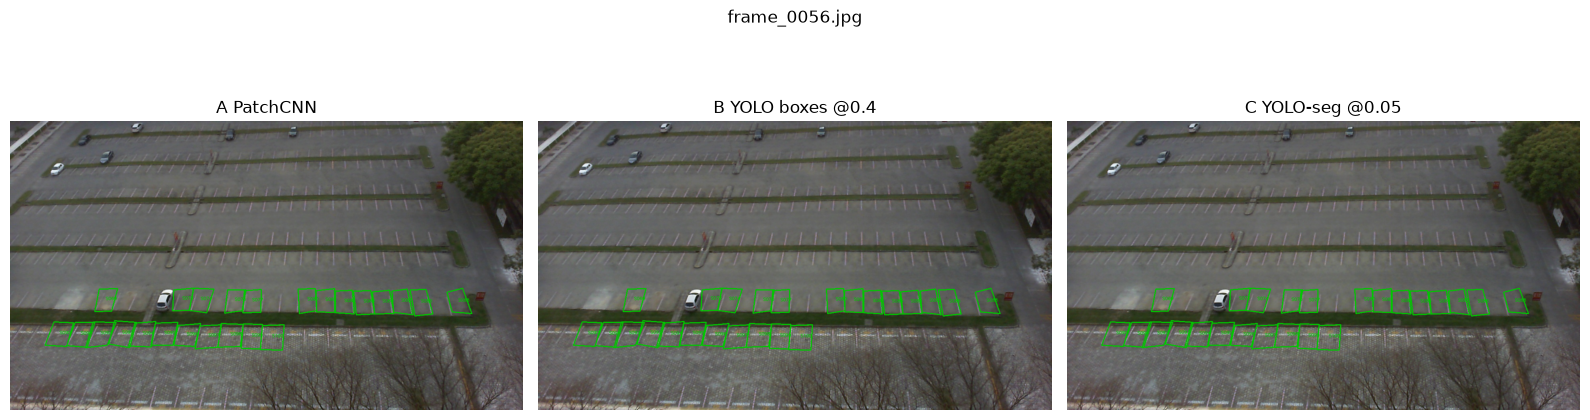

In [9]:
results = [metrics_a, metrics_b, metrics_c]
cmp = pd.DataFrame(results).sort_values("accuracy", ascending=False)
display(cmp)

winner = cmp.iloc[0].to_dict()
print("WINNER:", winner["approach"], f"acc={winner.get('accuracy', 0):.1%}")

(OUT / "comparison.json").write_text(json.dumps({
    "dataset": "Voxel51/PKLot",
    "lot": manifest[0]["source"],
    "n_frames_total": len(manifest),
    "n_test_frames": len(test_idx),
    "approaches": results,
    "winner": winner,
    "note": "datasets.load_dataset provides images; FiftyOne load_from_hub on the same repo provides polygons+occupancy.",
}, indent=2))

# Qualitative: one test frame, all three methods
qi = test_idx[0]
entry = manifest[qi]
img = load_bgr(FRAMES / entry["frame"])
st_a = predict_a_frame(img, entry["spaces"])
st_b, _, dets_b = decide_b(img, entry["spaces"], thr=BEST_B_THR)
st_c, _, _ = decide_c(img, entry["spaces"], thr=BEST_C_THR)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, st, title in zip(axes, [st_a, st_b, st_c], ["A PatchCNN", f"B YOLO boxes @{BEST_B_THR}", f"C YOLO-seg @{BEST_C_THR}"]):
    vis = overlay_rois(img, entry["spaces"], st)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.suptitle(entry["frame"])
plt.tight_layout()
plt.show()


## 8 · Feasibility report


In [10]:
report = f"""# Feasibility Report — PKLot 3-Approach Comparison

## Dataset
- **Hub:** [Voxel51/PKLot](https://huggingface.co/datasets/Voxel51/PKLot)
- **Load API:** `datasets.load_dataset("Voxel51/PKLot")` (images)
- **Labels:** FiftyOne `load_from_hub("Voxel51/PKLot")` (polygons + occupancy) — required because the datasets parquet export is **image-only**
- **License:** CC BY 4.0 (cite Almeida et al., ESWA 2015)
- **Subset:** lot=`{manifest[0]["source"]}`, weather≈{WEATHER}, frames={len(manifest)}, spots/frame≤{MAX_SPOTS_PER_FRAME}

## Approaches
1. **A — Patch CNN:** train free/occupied on ROI crops (same family as mAlexNet/MobileNet papers; no torchvision to avoid Colab PIL bugs).
2. **B — YOLOv8n + ROI overlap:** zero-shot COCO detector (feasibility default).
3. **C — YOLOv8n-seg + ROI IoU/coverage:** zero-shot masks for tighter geometry.

## Results (held-out frames)
{cmp.to_markdown(index=False)}

**Winner:** `{winner["approach"]}` · accuracy={winner.get("accuracy", float("nan")):.1%} · mean latency={winner.get("latency_mean_s", float("nan")):.3f}s

Targets: ≥90% accuracy, <3s / frame.

## Limitations
- PKLot is parking-lot elevated cams, **not** curb-side street parking (domain gap).
- Full Hub set is ~12k images / ~4GB — this notebook uses a capped subset for Colab.
- Approach A can overfit the lot it was trained on; retrain for a new camera.
- Approaches B/C need ROI polygons defined once per fixed camera.

## Project 2
- Collect target-street labeled frames; re-tune thresholds / fine-tune patch CNN.
- Add temporal smoothing; consider homography for oblique street views.
"""
(REPORTS / "feasibility_report.md").write_text(report)
display(Markdown(report))
print("Saved", REPORTS / "feasibility_report.md")


# Feasibility Report — PKLot 3-Approach Comparison

## Dataset
- **Hub:** [Voxel51/PKLot](https://huggingface.co/datasets/Voxel51/PKLot)
- **Load API:** `datasets.load_dataset("Voxel51/PKLot")` (images)
- **Labels:** FiftyOne `load_from_hub("Voxel51/PKLot")` (polygons + occupancy) — required because the datasets parquet export is **image-only**
- **License:** CC BY 4.0 (cite Almeida et al., ESWA 2015)
- **Subset:** lot=`pucpr`, weather≈sunny, frames=80, spots/frame≤24

## Approaches
1. **A — Patch CNN:** train free/occupied on ROI crops (same family as mAlexNet/MobileNet papers; no torchvision to avoid Colab PIL bugs).
2. **B — YOLOv8n + ROI overlap:** zero-shot COCO detector (feasibility default).
3. **C — YOLOv8n-seg + ROI IoU/coverage:** zero-shot masks for tighter geometry.

## Results (held-out frames)
| approach              |   n |   accuracy |   precision_occupied |   recall_occupied |   precision_free |   recall_free |   latency_mean_s |   latency_p95_s |   best_thr |
|:----------------------|----:|-----------:|---------------------:|------------------:|-----------------:|--------------:|-----------------:|----------------:|-----------:|
| B_YOLOv8n_overlap@0.4 | 576 |   0.609375 |                    1 |         0.0778689 |         0.59605  |             1 |         0.413258 |        0.54758  |       0.4  |
| C_YOLOv8nseg_iou@0.05 | 576 |   0.597222 |                    1 |         0.0491803 |         0.588652 |             1 |         0.831245 |        1.23863  |       0.05 |
| A_PatchCNN            | 576 |   0.576389 |                    0 |         0         |         0.576389 |             1 |         0.370581 |        0.491274 |     nan    |

**Winner:** `B_YOLOv8n_overlap@0.4` · accuracy=60.9% · mean latency=0.413s

Targets: ≥90% accuracy, <3s / frame.

## Limitations
- PKLot is parking-lot elevated cams, **not** curb-side street parking (domain gap).
- Full Hub set is ~12k images / ~4GB — this notebook uses a capped subset for Colab.
- Approach A can overfit the lot it was trained on; retrain for a new camera.
- Approaches B/C need ROI polygons defined once per fixed camera.

## Project 2
- Collect target-street labeled frames; re-tune thresholds / fine-tune patch CNN.
- Add temporal smoothing; consider homography for oblique street views.


Saved /content/parking_mvp/reports/feasibility_report.md
